In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [25]:
df = pd.read_csv('lab2_machine_learning_dataset.csv')

print("Shape of dataset:", df.shape)

print("\n--- Data Types ---")
print(df.dtypes)

print("\n--- Summary Statistics ---")
print(df.describe(include='all'))

print("\n--- Missing Values ---")
print(df.isnull().sum())

print("\n--- Duplicate Records ---")
print("Total duplicates:", df.duplicated().sum())

print("\n--- Class Distribution (Is_Promoted) ---")
print(df['Is_Promoted'].value_counts())

Shape of dataset: (16, 6)

--- Data Types ---
ID                     int64
Age                  float64
Department               str
Salary               float64
Performance_Score        str
Is_Promoted              str
dtype: object

--- Summary Statistics ---
               ID         Age Department        Salary Performance_Score  \
count   16.000000   14.000000         15     14.000000                16   
unique        NaN         NaN          3           NaN                 3   
top           NaN         NaN         IT           NaN              High   
freq          NaN         NaN          6           NaN                 6   
mean     7.812500  102.071429        NaN  67642.857143               NaN   
std      4.385107  258.303478        NaN  13809.735378               NaN   
min      1.000000   22.000000        NaN  45000.000000               NaN   
25%      4.750000   27.250000        NaN  56250.000000               NaN   
50%      7.500000   30.500000        NaN  69000.000000

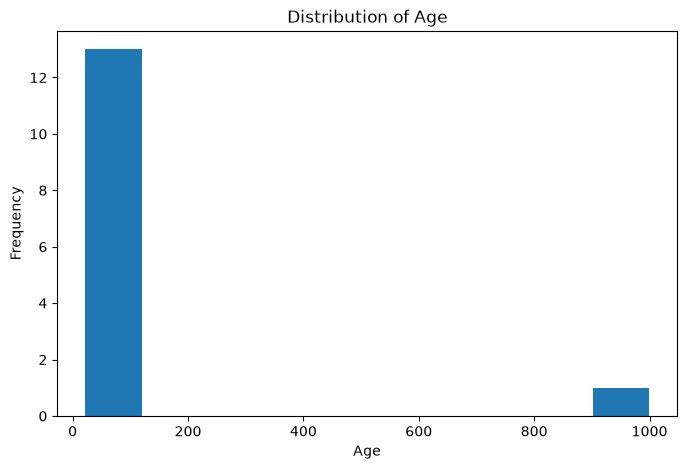

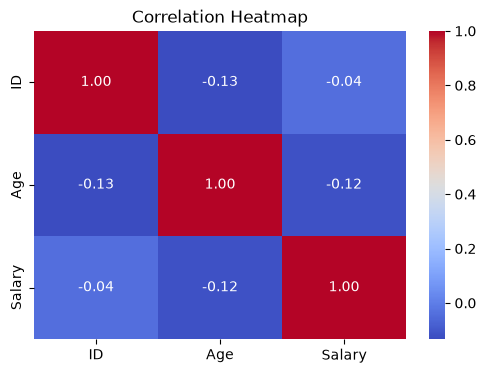

In [26]:
plt.figure(figsize=(8, 5))
plt.hist(df['Age'])
plt.title('Distribution of Age')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

plt.figure(figsize=(6, 4))

numeric_df = df.select_dtypes(include=['int64', 'float64'])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()

In [27]:
df['Salary'] = pd.to_numeric(df['Salary'], errors='coerce')

df.loc[df['Age'] > 100, 'Age'] = np.nan

df = df.drop_duplicates().reset_index(drop=True)

print("Mean Age:", df['Age'].mean())
print("Median Age:", df['Age'].median())

df['Age'] = df['Age'].fillna(df['Age'].median())
df['Salary'] = df['Salary'].fillna(df['Salary'].median())

df['Department'] = df['Department'].fillna(df['Department'].mode()[0])

print("\nตรวจสอบค่าว่างอีกครั้งหลังจาก Clean Data:")
print(df.isnull().sum())

Mean Age: 32.083333333333336
Median Age: 29.5

ตรวจสอบค่าว่างอีกครั้งหลังจาก Clean Data:
ID                   0
Age                  0
Department           0
Salary               0
Performance_Score    0
Is_Promoted          0
dtype: int64


In [28]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

performance_mapping = {'Low': 0, 'Medium': 1, 'High': 2}
df['Performance_Score_Encoded'] = df['Performance_Score'].map(performance_mapping)

print("--- After Label Encoding ---")
print(df[['Performance_Score', 'Performance_Score_Encoded']].head())


df = pd.get_dummies(df, columns=['Department'], prefix='Dept')

print("\n--- After One-Hot Encoding (Top 5 rows) ---")
print(df.head())

--- After Label Encoding ---
  Performance_Score  Performance_Score_Encoded
0              High                          2
1            Medium                          1
2              High                          2
3               Low                          0
4            Medium                          1

--- After One-Hot Encoding (Top 5 rows) ---
   ID   Age   Salary Performance_Score Is_Promoted  Performance_Score_Encoded  \
0   1  25.0  50000.0              High         Yes                          2   
1   2  30.0  70000.0            Medium          No                          1   
2   3  29.5  75000.0              High         Yes                          2   
3   4  22.0  68000.0               Low          No                          0   
4   5  45.0  80000.0            Medium         Yes                          1   

   Dept_HR  Dept_IT  Dept_Sales  
0     True    False       False  
1    False     True       False  
2    False     True       False  
3    False    False  